# PR & PPR Concept

## Dataset Convert:

- **Directed Graph**
- **Source $\to$ Collabos**
- **Source: 구심점 정보**
- Circular 가능하게 (Not DAG)
- (Example) A - B,C,D 에서 $\gamma \in (0, 1)$
  - **A: host**
  - **B, C, D: guests**
  - PR & PPR: A - B | A - C | A - D | 로 분리 필요. => Guests간의 links 정보 유실
  - IDEA: discount factor
    | Link | Count |
    | :---: | :---: |
    | A $\to$ B | 1 |
    | A $\to$ C | 1 |
    | A $\to$ D | 1 |
    | B - C | $\gamma$|
    | B - D | $\gamma$|
    | C - D | $\gamma$|
  - Also, Di Graph => Guests간의 Direction?
  - B - C의 경우, $B \to C$ & $C \to B$ 각각 만들기.

## Example

$\gamma \in (0, 1)$

| Link | Count |
| :---: | :---: |
| $A\to B$ | 1 |
| $A\to C$ | 1 |
| $A\to D$ | 1 |
| $B\to C$ | $0.5\cdot\gamma$ |
| $C\to B$ | $0.5\cdot\gamma$ |
| $B\to D$ | $0.5\cdot\gamma$ |
| $D\to B$ | $0.5\cdot\gamma$ |
| $C\to D$ | $0.5\cdot\gamma$ |
| $D\to C$ | $0.5\cdot\gamma$ |

***

### Dataset Conver for PR & PPR

- Later: Temporal analysis - Date 정보.. 사용
- $\gamma = 0.5$ 사용

In [2]:
import pandas as pd
from itertools import combinations

gamma = 0.5  # 나중에 조정 가능

df = pd.read_csv("../../Dataset/data_260429.csv")

edges = []

for _, row in df.iterrows():
    source = row["Source_Channel"]
    collabs = [c.strip() for c in str(row["Collab_Channel"]).split(", ")]
    
    # Source → 각 Collab: count = 1
    for collab in collabs:
        edges.append((source, collab, 1.0))
    
    # Collab 간 양방향: count = 0.5 * gamma
    for c1, c2 in combinations(collabs, 2):
        edges.append((c1, c2, 0.5 * gamma))
        edges.append((c2, c1, 0.5 * gamma))

edge_df = pd.DataFrame(edges, columns=["Source", "Target", "Count"])

# 같은 (Source, Target) 쌍은 Count 합산
edge_df = edge_df.groupby(["Source", "Target"], as_index=False)["Count"].sum()

edge_df.to_csv("../../Dataset/edge_260429.csv", index=False, encoding="utf-8-sig")
print(edge_df.head(10))
print(f"\n총 엣지 수: {len(edge_df)}")

  Source        Target  Count
0   1분마뫄            강지   1.00
1   1분마뫄            러너  11.00
2   1분마뫄           백곰파   0.25
3   1분마뫄           빅헤드   3.00
4   1분마뫄           사모장   0.25
5   1분마뫄            서넹   1.00
6   1분마뫄  일루전 ILLUSION   1.00
7   1분마뫄          쫀득TV   1.00
8   1분마뫄           치킨쿤   1.00
9   1분마뫄    코렛트YouTube   2.00

총 엣지 수: 3390


***

### PR

damping factor: alpha=0.85


=== PageRank Top 20 ===
      Channel  PageRank
0      양띵 유튜브  0.032485
1          삼식  0.029272
2          다주  0.027059
3          후추  0.026978
4          서넹  0.025211
5          너불  0.022903
6          핑맨  0.020228
7        탬탬버린  0.019425
8          강지  0.018751
9        콩콩이다  0.018052
10  YouTube지누  0.016623
11        왈도쿤  0.016225
12         코마  0.015544
13         김뿡  0.014944
14      중력유튜브  0.013551
15        파이브  0.013450
16         러끼  0.013197
17        장마군  0.012983
18         악녀  0.012767
19        백곰파  0.011607


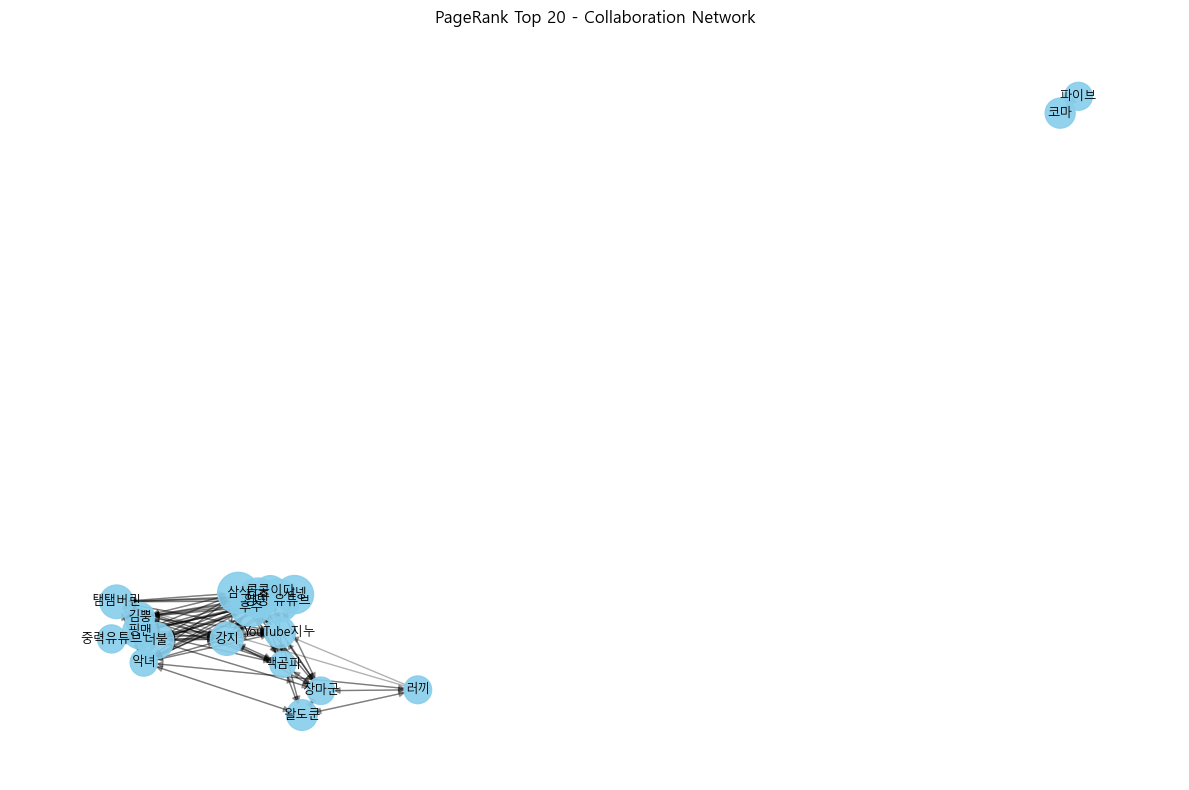

In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np

random.seed(42)
np.random.seed(42)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

edge_df = pd.read_csv("../../Dataset/edge_260429.csv")

G = nx.DiGraph()
for _, row in edge_df.iterrows():
    G.add_edge(row["Source"], row["Target"], weight=row["Count"])

pr = nx.pagerank(G, alpha=0.85, weight="weight")
pr_df = pd.DataFrame(pr.items(), columns=["Channel", "PageRank"])
pr_df = pr_df.sort_values("PageRank", ascending=False).reset_index(drop=True)

print("\n=== PageRank Top 20 ===")
print(pr_df.head(20))

# Top 20 노드만 서브그래프로 시각화
top20_nodes = pr_df.head(20)["Channel"].tolist()
subG = G.subgraph(top20_nodes)

node_size = [pr[n] * 30000 for n in subG.nodes()]  # PR 크기 반영
pos = nx.spring_layout(subG)

plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(subG, pos, node_size=node_size, node_color="skyblue", alpha=0.9)
nx.draw_networkx_edges(subG, pos, alpha=0.3, arrows=True)
nx.draw_networkx_labels(subG, pos, font_family="Malgun Gothic", font_size=9)
plt.title("PageRank Top 20 - Collaboration Network")
plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
from pyvis.network import Network
import pandas as pd
import networkx as nx

edge_df = pd.read_csv("../../Dataset/edge_260429.csv")

G = nx.DiGraph()
for _, row in edge_df.iterrows():
    G.add_edge(row["Source"], row["Target"], weight=row["Count"])

pr = nx.pagerank(G, alpha=0.85, weight="weight")
pr_df = pd.DataFrame(pr.items(), columns=["Channel", "PageRank"])
pr_df = pr_df.sort_values("PageRank", ascending=False).reset_index(drop=True)
top20_nodes = set(pr_df.head(20)["Channel"].tolist())

net = Network(height="800px", width="100%", directed=True, notebook=True)

for node in G.nodes():
    size = pr[node] * 3000
    color = "tomato" if node in top20_nodes else "skyblue"
    label = node if node in top20_nodes else ""
    net.add_node(node, label=label, size=size, color=color)

for u, v, data in G.edges(data=True):
    net.add_edge(u, v, value=data["weight"])

net.show("../../Graph/network_260429.html")

../../Graph/network_260429.html


***

### PPR


In [11]:
# In/Out-degree 상위 10
in_deg = sorted(G.in_degree(weight="weight"), key=lambda x: x[1], reverse=True)[:10]
out_deg = sorted(G.out_degree(weight="weight"), key=lambda x: x[1], reverse=True)[:10]

print("=== In-degree Top 10 ===")
for node, deg in in_deg:
    print(f"{node}: {deg:.2f}")

print("\n=== Out-degree Top 10 ===")
for node, deg in out_deg:
    print(f"{node}: {deg:.2f}")

=== In-degree Top 10 ===
양띵 유튜브: 821.00
삼식: 790.00
후추: 755.50
서넹: 741.00
다주: 663.50
너불: 548.25
콩콩이다: 519.75
핑맨: 398.75
중력유튜브: 350.25
강지: 234.75

=== Out-degree Top 10 ===
콩콩이다: 776.75
다주: 774.50
후추: 681.50
양띵 유튜브: 673.00
루태TV: 649.25
악어 유튜브: 566.75
서넹: 513.00
핑맨: 511.75
삼식: 408.00
중력유튜브: 376.25


- Count Check (Weighed Degree)
- seed 정리하면: (PPR target_channel)
  - 그룹 1 (허브): 양띵, 후추, 다주 (In/Out 둘 다 상위)
  - 그룹 2 (Out-only): 루태TV, 악어 유튜브 (Out 상위, PR 낮음)


In-degree 기준 → "많이 불린 채널" 관점
Out-degree 기준 → "많이 초대한 채널" 관점
In+Out 합산 → 전체 협업 강도

Later...